## Questions About Missing Rows in Datasets

I am reusing some of the code from my climate portfolio notebook to set up the context for my questions.

In [1]:
### import libraries
 
### work with tabular data
import pandas as pd ### work with tabular data
### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt
### common statistical plots for tabular data
import seaborn as sns
### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

In [2]:
### make URL for data
ncei_url = ('https://www.ncei.noaa.gov/access/services/da'
            'ta/v1?dataset=daily-summaries&dataTypes=TAVG&stations'
            '=TI000038836&startDate=1990-01-01&endDate=1999-12-31&units=standard')

ncei_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TAVG&stations=TI000038836&startDate=1990-01-01&endDate=1999-12-31&units=standard'

In [3]:
### get the data using URL
dushanbe_temp_df = pd.read_csv(
    ncei_url, 

    ### set the index column to DATE
    index_col = 'DATE',

    ### parse the index column as date-time
    parse_dates = True,

    ### set NA values to NaN
    na_values = ['NaN']
    )

dushanbe_temp_df

,STATION,TAVG
DATE,,
1990-01-01,TI000038836,37.0
1990-01-02,TI000038836,40.0
1990-01-03,TI000038836,36.0
1990-01-04,TI000038836,35.0
1990-01-05,TI000038836,43.0
...,...,...
1999-12-26,TI000038836,38.0
1999-12-28,TI000038836,41.0
1999-12-29,TI000038836,44.0


In [4]:
### cleaning up
dushanbe_temp_df = dushanbe_temp_df[['TAVG']].rename(columns = {'TAVG': 'temp_fahr'})

dushanbe_temp_df

,temp_fahr
DATE,
1990-01-01,37.0
1990-01-02,40.0
1990-01-03,36.0
1990-01-04,35.0
1990-01-05,43.0
...,...
1999-12-26,38.0
1999-12-28,41.0
1999-12-29,44.0


In [5]:
### get the entries for a single month
dushanbe_temp_df.loc['1999-01-01':'1999-01-31']

,temp_fahr
DATE,
1999-01-05,17.0
1999-01-09,41.0
1999-01-24,40.0
1999-01-25,42.0


As we can see, most of the entries are missing.

In [6]:
### creating a df index that does not miss any days
full_dates = pd.date_range(
    start="1990-01-01",
    end="1999-12-31",
    freq="D"
)

complete_temp_df = dushanbe_temp_df.reindex(full_dates)

complete_temp_df.index.name = "DATE"

In [7]:
### comparing the two dataframes

print("BEFORE REINDEXING:")
display(dushanbe_temp_df.loc['1999-01-01':'1999-01-31'])

print("AFTER REINDEXING:")
display(complete_temp_df.loc['1999-01-01':'1999-01-31'])

BEFORE REINDEXING:


,temp_fahr
DATE,
1999-01-05,17.0
1999-01-09,41.0
1999-01-24,40.0
1999-01-25,42.0


AFTER REINDEXING:


,temp_fahr
DATE,
1999-01-01,NaN
1999-01-02,NaN
1999-01-03,NaN
1999-01-04,NaN
1999-01-05,17.0
1999-01-06,NaN
1999-01-07,NaN
1999-01-08,NaN
1999-01-09,41.0


In [8]:
### fill missing values with the mean of the column
meanfilled_complete_temp_df = complete_temp_df.fillna(complete_temp_df.mean())

meanfilled_complete_temp_df.loc['1999-01-01':'1999-01-31']

,temp_fahr
DATE,
1999-01-01,60.168565
1999-01-02,60.168565
1999-01-03,60.168565
1999-01-04,60.168565
1999-01-05,17.000000
1999-01-06,60.168565
1999-01-07,60.168565
1999-01-08,60.168565
1999-01-09,41.000000


In [9]:
### fill missing values with linear interpolation
interpol_complete_temp_df = complete_temp_df.interpolate(method='linear')

interpol_complete_temp_df.loc['1999-01-01':'1999-01-31']

,temp_fahr
DATE,
1999-01-01,28.000000
1999-01-02,25.250000
1999-01-03,22.500000
1999-01-04,19.750000
1999-01-05,17.000000
1999-01-06,23.000000
1999-01-07,29.000000
1999-01-08,35.000000
1999-01-09,41.000000


/tmp/ipykernel_67503/770199448.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


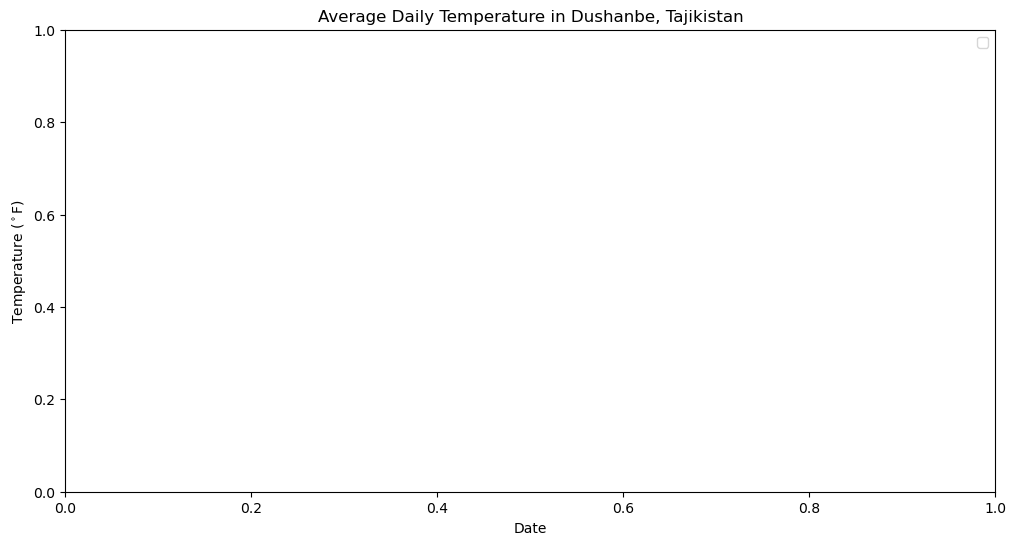

In [10]:
### set the figure size for all plots
fig, ax = plt.subplots(figsize=(12, 6))

ax.set_title('Average Daily Temperature in Dushanbe, Tajikistan')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature ($^\circ$F)')
ax.legend()

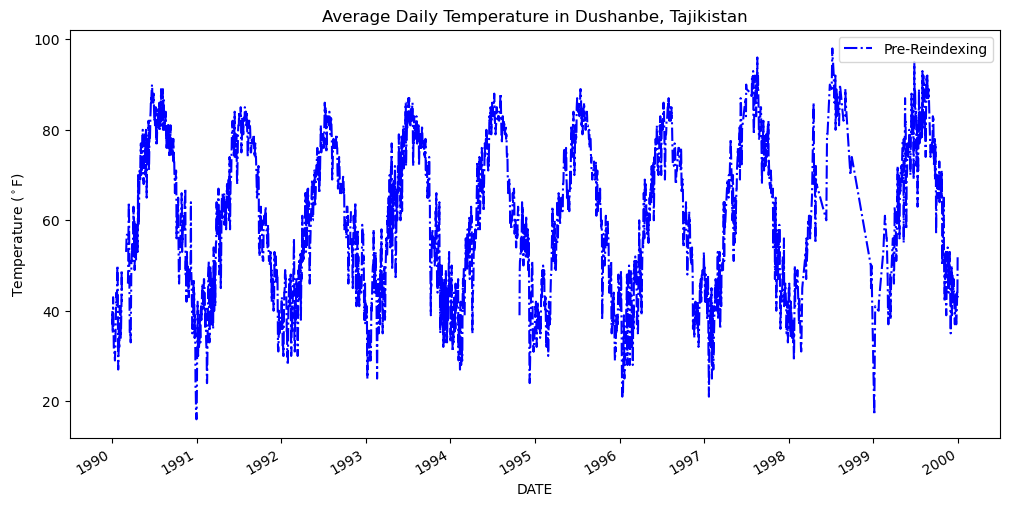

In [11]:
### plot the data for pre-reindexing
dushanbe_temp_df.plot(
        y = 'temp_fahr',
        label = 'Pre-Reindexing',
        color = 'blue',
        linestyle = '-.',
        ax = ax)

fig

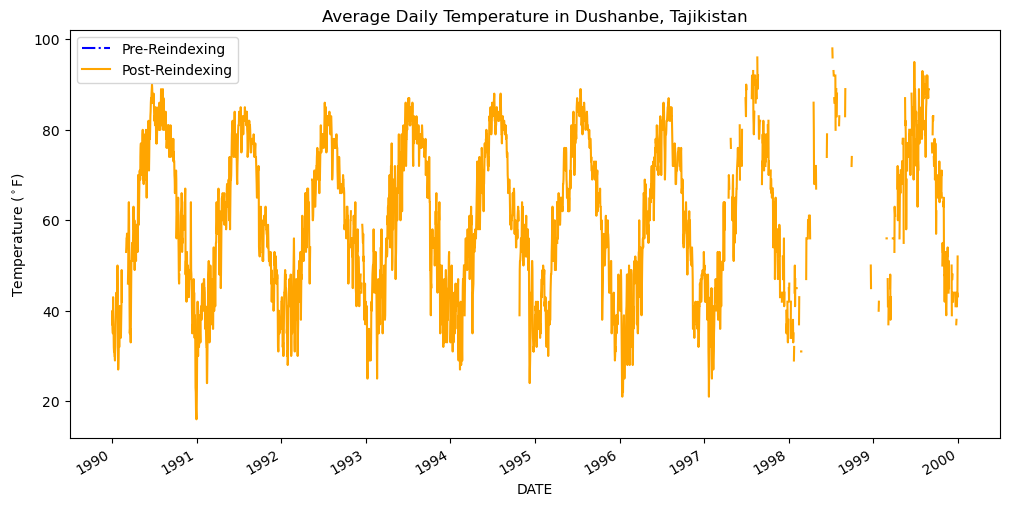

In [12]:
### plot the data for post-reindexing
complete_temp_df.plot(
        y = 'temp_fahr',
        label = 'Post-Reindexing',
        color = 'orange',
        ax = ax)

### hide the first plot for better visualization of the second plot
ax.lines[0].set_visible(False)

fig

As we can see, the post-indexing plot has gaps.

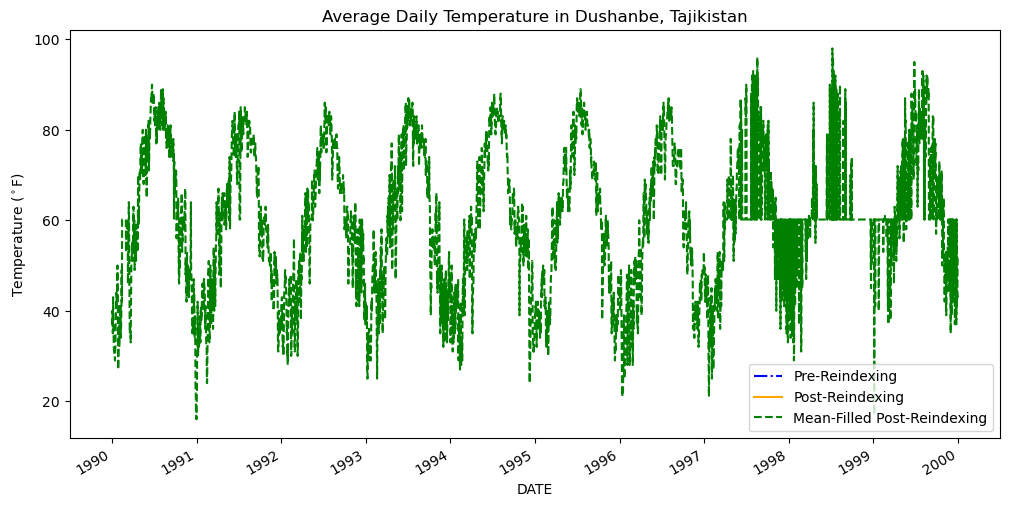

In [13]:
### plot the data for post-reindexing with mean-filled values
meanfilled_complete_temp_df.plot(
        y = 'temp_fahr',
        label = 'Mean-Filled Post-Reindexing',
        color = 'green',
        linestyle = '--',
        ax = ax)


### hide the second plot for better visualization of the third plot
ax.lines[1].set_visible(False)

fig

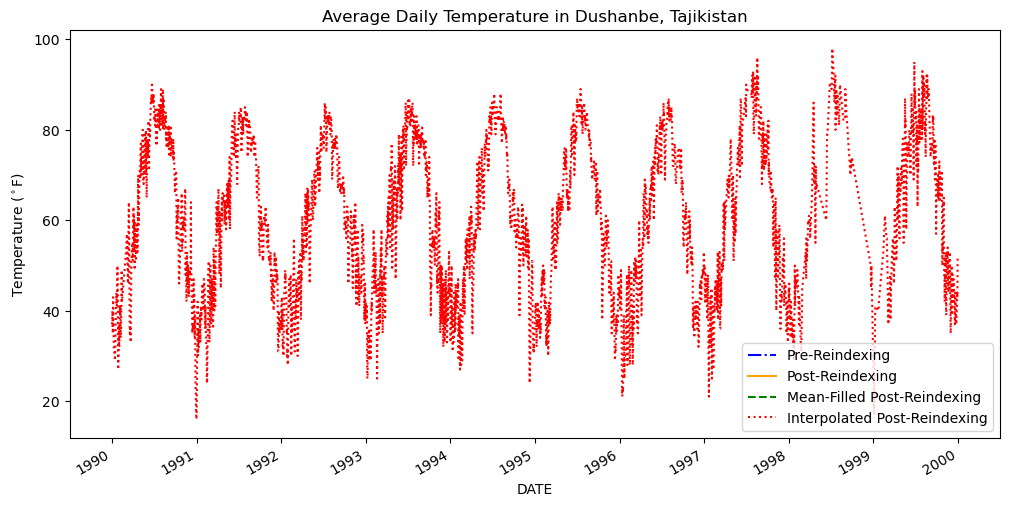

In [14]:
### plot the data for post-reindexing
interpol_complete_temp_df.plot(
        y = 'temp_fahr',
        label = 'Interpolated Post-Reindexing',
        color = 'red',
        linestyle = ':',
        ax = ax)


### hide the third plot for better visualization of the fourth plot
ax.lines[2].set_visible(False)

fig

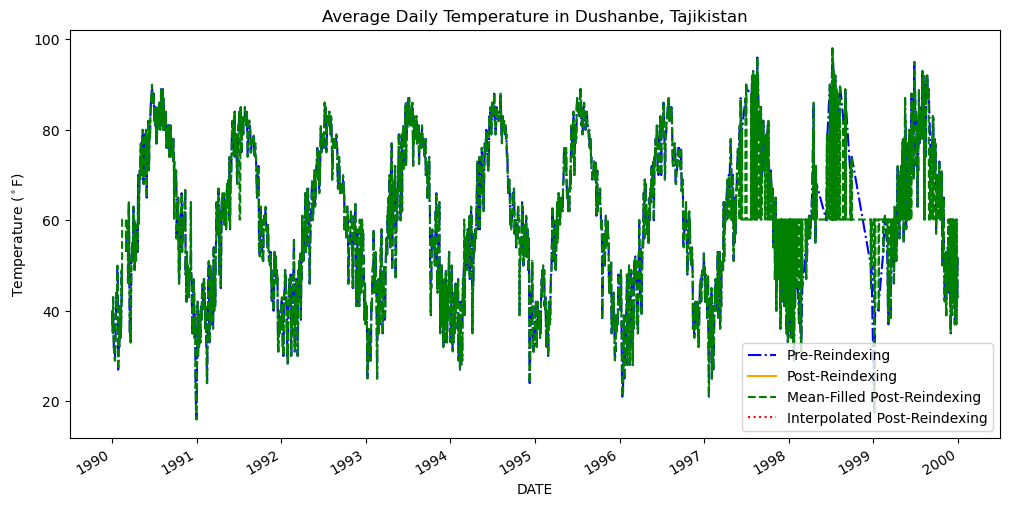

In [15]:
### compare the way pre-indexing 
### and mean-filled post-indexing data look

for i in [1, 3]:
    ax.lines[i].set_visible(False)

for k in [0, 2]:
    ax.lines[k].set_visible(True)

fig

The filling looks different.

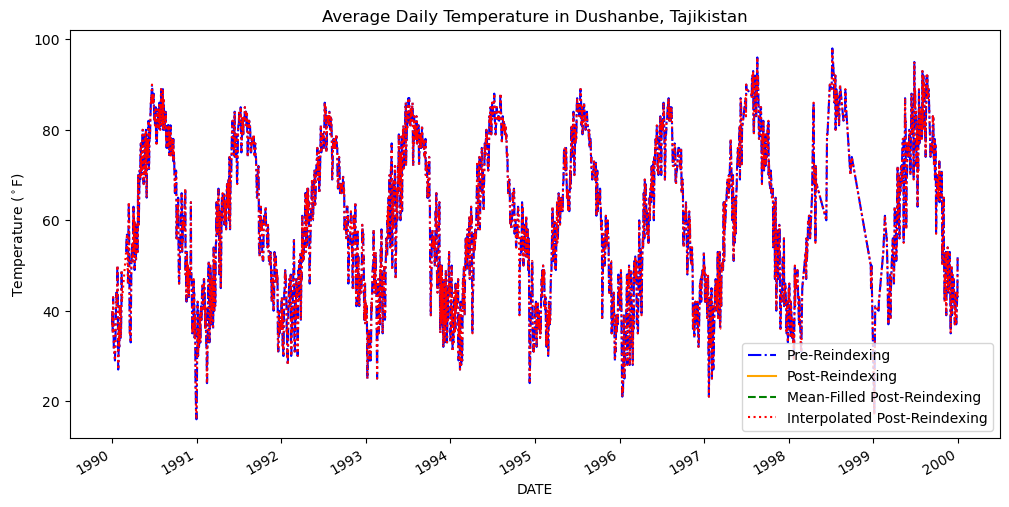

In [16]:
### compare the way pre-indexing 
### and interpolated post-indexing data look

for i in [1, 2]:
    ax.lines[i].set_visible(False)

for k in [0, 3]:
    ax.lines[k].set_visible(True)

fig

The filling looks the same.

In [17]:
### resample pre-reindexed data to ann. freq. with mean
dush_ann_temp_df = (

    ### resample df
    dushanbe_temp_df

    ### sample annually
    .resample('YS')

    ### take mean
    .mean()
)

dush_ann_temp_df

,temp_fahr
DATE,
1990-01-01,62.084548
1991-01-01,58.628809
1992-01-01,58.851852
1993-01-01,59.312329
1994-01-01,60.019391
1995-01-01,59.806094
1996-01-01,57.945355
1997-01-01,59.134387
1998-01-01,62.714286


In [18]:
### resample post-reindexed data to ann. freq. with mean
complete_ann_temp_df = (

    ### resample df
    complete_temp_df

    ### sample annually
    .resample('YS')

    ### take mean
    .mean()
)

complete_ann_temp_df

,temp_fahr
DATE,
1990-01-01,62.084548
1991-01-01,58.628809
1992-01-01,58.851852
1993-01-01,59.312329
1994-01-01,60.019391
1995-01-01,59.806094
1996-01-01,57.945355
1997-01-01,59.134387
1998-01-01,62.714286


The resampling of pre-reindex and post-reindex gave similar outputs.

In [19]:
### resample mean-filled post-reindexed data to ann. freq. with mean
meanfilled_complete_ann_temp_df = (

    ### resample df
    meanfilled_complete_temp_df

    ### sample annually
    .resample('YS')

    ### take mean
    .mean()
)

meanfilled_complete_ann_temp_df

,temp_fahr
DATE,
1990-01-01,61.969064
1991-01-01,58.645683
1992-01-01,58.905816
1993-01-01,59.312329
1994-01-01,60.021025
1995-01-01,59.810066
1996-01-01,57.945355
1997-01-01,59.451724
1998-01-01,60.754429


Different output compared to pre/post-reindexing.

In [20]:
### resample interpolated post-reindexed data to ann. freq. with mean
interpol_complete_ann_temp_df = (

    ### resample df
    interpol_complete_temp_df

    ### sample annually
    .resample('YS')

    ### take mean
    .mean()
)

interpol_complete_ann_temp_df

,temp_fahr
DATE,
1990-01-01,61.313699
1991-01-01,58.890411
1992-01-01,58.759563
1993-01-01,59.312329
1994-01-01,59.876712
1995-01-01,59.783562
1996-01-01,57.945355
1997-01-01,63.084932
1998-01-01,64.332877


Different output compared to pre/post-reindexing.

/tmp/ipykernel_67503/4009486580.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


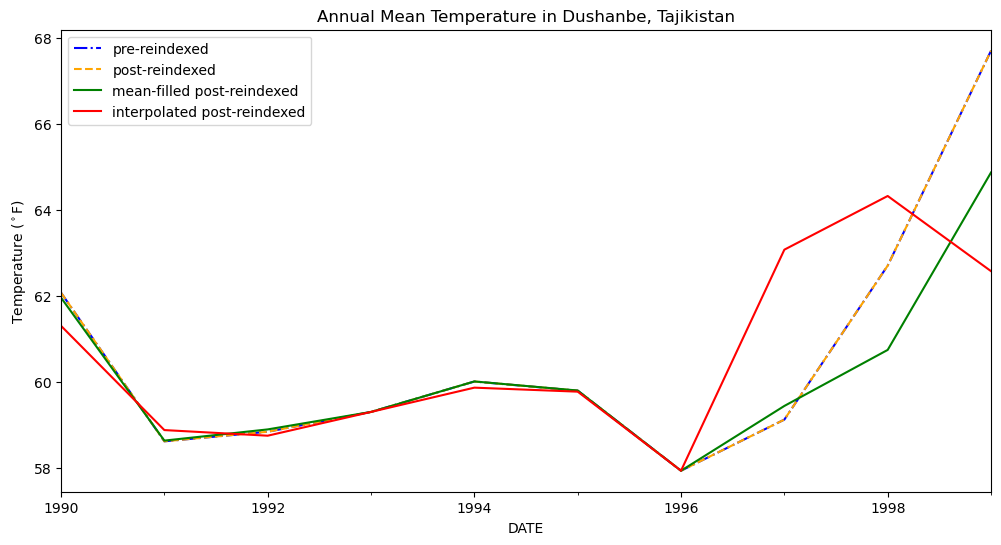

In [21]:
### plot all resampled dfs for comparison

fig, ax = plt.subplots(figsize=(12, 6))

ax.set_title('Annual Mean Temperature in Dushanbe, Tajikistan')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature ($^\circ$F)')
ax.legend()

dush_ann_temp_df.plot(
    y = 'temp_fahr',
    label = "pre-reindexed",
    color = 'blue',
    linestyle = '-.',
    ax = ax
)

complete_ann_temp_df.plot(
    y = 'temp_fahr',
    label = "post-reindexed",
    color = 'orange',
    linestyle = '--',
    ax = ax
)

meanfilled_complete_ann_temp_df.plot(
    y = 'temp_fahr',
    label = "mean-filled post-reindexed",
    color = 'green',
    ax = ax
)

interpol_complete_ann_temp_df.plot(
    y = 'temp_fahr',
    label = "interpolated post-reindexed",
    color = 'red',
    ax = ax
)



plt.show()

### My Questions
1- Why were the missing rows not causing a problem in the pre-reindex dataframe?

2- Why did the pre-reindex dataframe interpolate linearly (I am assuming, since the graphs look alike) -- in the pre-resampling plot -- instead of leaving gaps?

3- Why did the resampling change the behavior of the interpolated plot compared to the pre-reindex plot, but the pre-reindex and post-reindex plots behave the same?
* Does resampling ignore NaN values both in the numerator and denominator of mean?